# Exploratory Data Analysis (EDA)
## LLM Comparison Dataset

**Objective:**
Perform Exploratory Data Analysis (EDA) on the LLM Comparison Dataset to understand its structure, data quality, statistical properties, relationships, and insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("llm_comparison_dataset.csv")

# Display first 5 rows
df.head()

,Model,Provider,Context Window,Speed (tokens/sec),Latency (sec),Benchmark (MMLU),Benchmark (Chatbot Arena),Open-Source,Price / Million Tokens,Training Dataset Size,Compute Power,Energy Efficiency,Quality Rating,Speed Rating,Price Rating
0,DeepSeek-4,Deepseek,128000,95,2.74,85,1143,1,18.81,760952565,13,0.50,2,2,3
1,Llama-8,Meta AI,300000,284,3.21,71,1390,1,3.98,22891342,22,2.07,1,3,3
2,Llama-5,Meta AI,300000,225,2.95,85,1406,0,1.02,827422145,21,0.95,2,3,2
3,DeepSeek-3,Deepseek,2000000,242,12.89,72,1264,1,27.63,694305632,86,3.51,1,3,3
4,DeepSeek-8,Deepseek,1000000,71,3.80,77,1381,1,18.52,378552278,92,1.80,2,2,3


# 1. Dataset Overview

In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Shape of Dataset: (200, 15)

Column Names:
['Model', 'Provider', 'Context Window', 'Speed (tokens/sec)', 'Latency (sec)', 'Benchmark (MMLU)', 'Benchmark (Chatbot Arena)', 'Open-Source', 'Price / Million Tokens', 'Training Dataset Size', 'Compute Power', 'Energy Efficiency', 'Quality Rating', 'Speed Rating', 'Price Rating']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Model                      200 non-null    str    
 1   Provider                   200 non-null    str    
 2   Context Window             200 non-null    int64  
 3   Speed (tokens/sec)         200 non-null    int64  
 4   Latency (sec)              200 non-null    float64
 5   Benchmark (MMLU)           200 non-null    int64  
 6   Benchmark (Chatbot Arena)  200 non-null    int64  
 7   Open-Source                200 non-null    int64  
 8   Price / Million Tokens     200 non-null    float64
 9   Training Dataset Size      200 non-null    int64  
 10  Compute Power              200 non-null    int64  
 11  Energy Efficiency          200 non-null    float64
 12  Quality Rating             200 non-null    int64  
 13  Speed Rating               200 non-null    int64  
 14  Price

# 2. Missing Values

In [5]:
df.isnull().sum()

Model                        0
Provider                     0
Context Window               0
Speed (tokens/sec)           0
Latency (sec)                0
Benchmark (MMLU)             0
Benchmark (Chatbot Arena)    0
Open-Source                  0
Price / Million Tokens       0
Training Dataset Size        0
Compute Power                0
Energy Efficiency            0
Quality Rating               0
Speed Rating                 0
Price Rating                 0
dtype: int64

# 3. Duplicate Records

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 4. Statistical Summary

In [8]:
df.describe()

,Context Window,Speed (tokens/sec),Latency (sec),Benchmark (MMLU),Benchmark (Chatbot Arena),Open-Source,Price / Million Tokens,Training Dataset Size,Compute Power,Energy Efficiency,Quality Rating,Speed Rating,Price Rating
count,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.371800e+05,163.240000,9.358750,77.945000,1192.960000,0.490000,14.475200,4.902643e+08,46.915000,2.519100,1.900000,2.275000,2.910000
std,6.909439e+05,79.188106,5.489481,10.182356,174.649767,0.501154,8.890484,2.747544e+08,28.408679,1.458241,0.802008,0.625565,0.303911
min,1.280000e+05,20.000000,0.600000,60.000000,902.000000,0.000000,0.200000,2.012584e+06,2.000000,0.150000,1.000000,1.000000,1.000000
25%,2.000000e+05,93.750000,4.265000,69.000000,1043.250000,0.000000,6.090000,2.622976e+08,22.000000,1.150000,1.000000,2.000000,3.000000
50%,2.560000e+05,165.500000,8.820000,80.000000,1200.500000,0.000000,14.660000,5.002494e+08,43.500000,2.525000,2.000000,2.000000,3.000000
75%,1.000000e+06,236.000000,14.035000,87.000000,1343.750000,1.000000,21.515000,7.210857e+08,72.000000,3.807500,3.000000,3.000000,3.000000
max,2.000000e+06,294.000000,19.800000,94.000000,1493.000000,1.000000,29.890000,9.844345e+08,99.000000,4.980000,3.000000,3.000000,3.000000


# 5. Provider Distribution

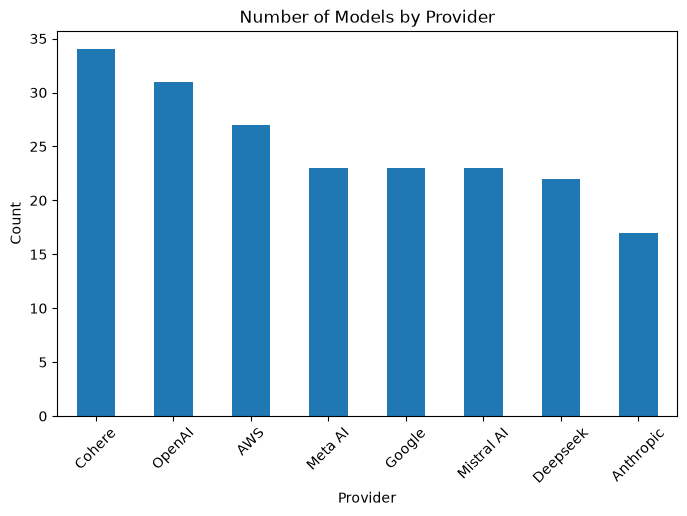

In [9]:
provider_counts = df["Provider"].value_counts()

provider_counts.plot(kind='bar', figsize=(8,5))

plt.title("Number of Models by Provider")
plt.xlabel("Provider")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 6. Average Benchmark Score by Provider

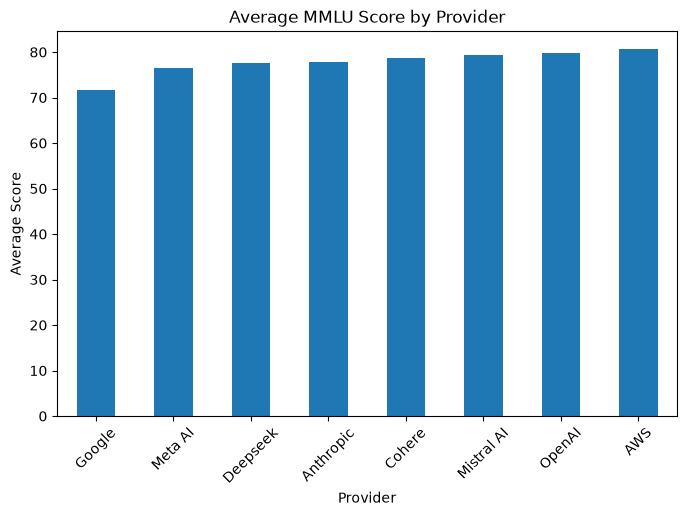

In [11]:
benchmark = df.groupby("Provider")["Benchmark (MMLU)"].mean().sort_values()

benchmark.plot(kind='bar', figsize=(8,5))

plt.title("Average MMLU Score by Provider")
plt.ylabel("Average Score")
plt.xticks(rotation=45)

plt.show()

# 7. Speed Distribution

In [20]:
df.columns

Index(['Model', 'Provider', 'Context Window', 'Speed (tokens/sec)',
       'Latency (sec)', 'Benchmark (MMLU)', 'Benchmark (Chatbot Arena)',
       'Open-Source', 'Price / Million Tokens', 'Training Dataset Size',
       'Compute Power', 'Energy Efficiency', 'Quality Rating', 'Speed Rating',
       'Price Rating'],
      dtype='str')

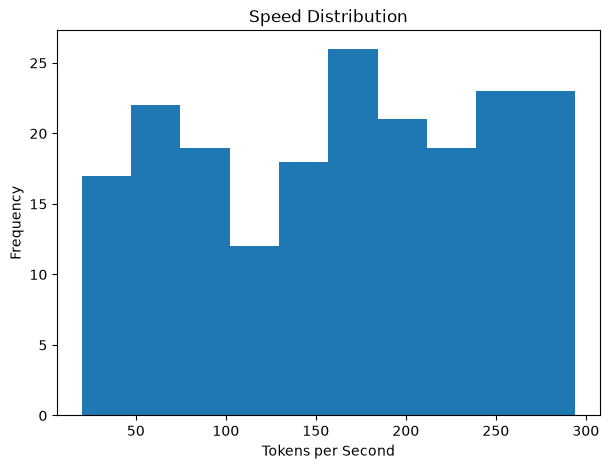

In [21]:
plt.figure(figsize=(7,5))

plt.hist(df["Speed (tokens/sec)"], bins=10)

plt.title("Speed Distribution")
plt.xlabel("Tokens per Second")
plt.ylabel("Frequency")

plt.show()

# 8. Price Distribution

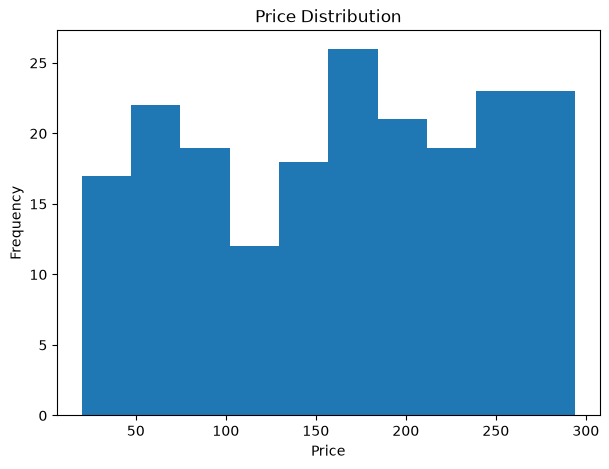

In [22]:
plt.figure(figsize=(7,5))

plt.hist(df["Speed (tokens/sec)"], bins=10)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

# 9. Latency Distribution

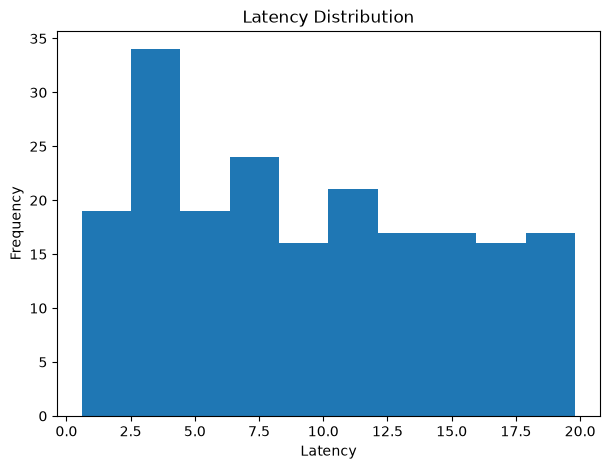

In [23]:
plt.figure(figsize=(7,5))

plt.hist(df["Latency (sec)"], bins=10)

plt.title("Latency Distribution")

plt.xlabel("Latency")

plt.ylabel("Frequency")

plt.show()

# 10. Price vs Benchmark

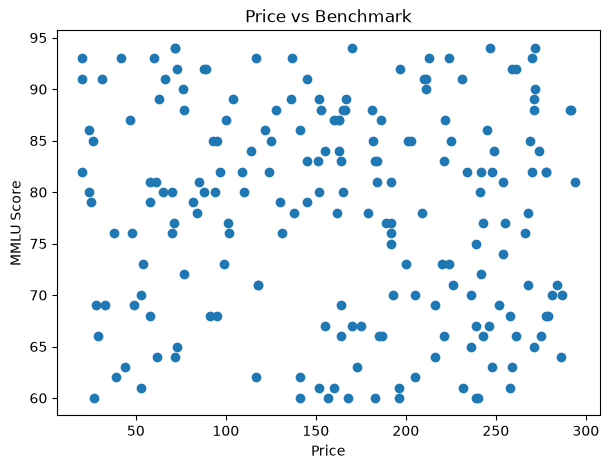

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(df["Speed (tokens/sec)"],
            df["Benchmark (MMLU)"])

plt.xlabel("Price")

plt.ylabel("MMLU Score")

plt.title("Price vs Benchmark")

plt.show()

# 11. Speed vs Latency

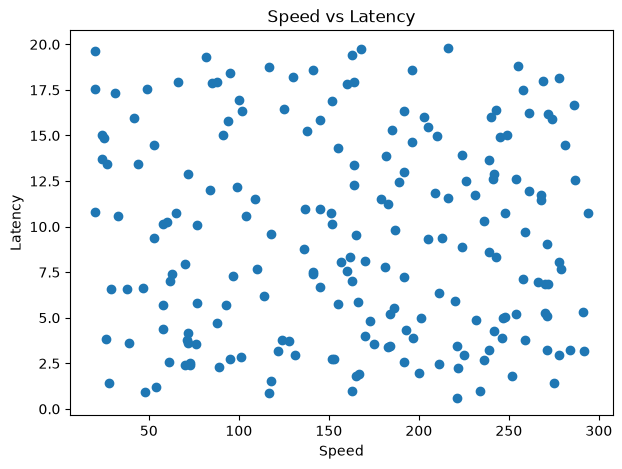

In [27]:
plt.figure(figsize=(7,5))

plt.scatter(df["Speed (tokens/sec)"],
            df["Latency (sec)"])

plt.xlabel("Speed")

plt.ylabel("Latency")

plt.title("Speed vs Latency")

plt.show()

# 12. Correlation Matrix

In [17]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Context Window,Speed (tokens/sec),Latency (sec),Benchmark (MMLU),Benchmark (Chatbot Arena),Open-Source,Price / Million Tokens,Training Dataset Size,Compute Power,Energy Efficiency,Quality Rating,Speed Rating,Price Rating
Context Window,1.000000,-0.058298,-0.029914,0.012680,0.058405,-0.041964,-0.038123,-0.055029,0.013043,-0.065421,0.014796,-0.074324,-0.029645
Speed (tokens/sec),-0.058298,1.000000,-0.026058,-0.087034,0.096613,0.033236,0.007032,-0.023523,0.008191,0.004908,-0.115062,0.885257,0.017189
Latency (sec),-0.029914,-0.026058,1.000000,-0.029991,-0.017392,0.070329,-0.036013,-0.087431,-0.027517,-0.029149,-0.016191,-0.062311,-0.096425
Benchmark (MMLU),0.012680,-0.087034,-0.029991,1.000000,0.133339,0.040759,-0.022233,0.115637,0.079877,-0.043380,0.935881,-0.048893,0.025998
Benchmark (Chatbot Arena),0.058405,0.096613,-0.017392,0.133339,1.000000,-0.041571,-0.065914,0.147797,0.060603,-0.019252,0.132030,0.075118,0.036855
Open-Source,-0.041964,0.033236,0.070329,0.040759,-0.041571,1.000000,0.115323,-0.051929,0.039295,0.106018,0.060012,-0.031256,0.093042
Price / Million Tokens,-0.038123,0.007032,-0.036013,-0.022233,-0.065914,0.115323,1.000000,0.075733,0.038056,0.005423,-0.010350,0.005109,0.448339
Training Dataset Size,-0.055029,-0.023523,-0.087431,0.115637,0.147797,-0.051929,0.075733,1.000000,-0.100852,0.070124,0.091060,-0.045348,0.128848
Compute Power,0.013043,0.008191,-0.027517,0.079877,0.060603,0.039295,0.038056,-0.100852,1.000000,-0.006715,0.101301,0.032709,0.045672
Energy Efficiency,-0.065421,0.004908,-0.029149,-0.043380,-0.019252,0.106018,0.005423,0.070124,-0.006715,1.000000,-0.042873,0.009417,0.075447


# 13. Top 10 Most Expensive Models

In [30]:
df.sort_values("Speed (tokens/sec)",
               ascending=False)[["Model","Provider","Speed (tokens/sec)"]].head(10)

,Model,Provider,Speed (tokens/sec)
48,Nova-3,AWS,294
187,Gemini-6,Google,292
93,DeepSeek-6,Deepseek,291
161,Mistral-7,Mistral AI,287
128,Gemini-8,Google,286
1,Llama-8,Meta AI,284
190,Gemini-1,Google,281
151,Gemini-6,Google,279
160,Nova-3,AWS,278
89,Claude-9,Anthropic,278


# 14. Top 10 Fastest Models

In [25]:
df.sort_values("Speed (tokens/sec)",
               ascending=False)[["Model","Provider","Speed (tokens/sec)"]].head(10)

,Model,Provider,Speed (tokens/sec)
48,Nova-3,AWS,294
187,Gemini-6,Google,292
93,DeepSeek-6,Deepseek,291
161,Mistral-7,Mistral AI,287
128,Gemini-8,Google,286
1,Llama-8,Meta AI,284
190,Gemini-1,Google,281
151,Gemini-6,Google,279
160,Nova-3,AWS,278
89,Claude-9,Anthropic,278


# 15. Insights

## Key Findings

- The dataset contains information about different Large Language Models (LLMs) from multiple providers.
- No missing values were found.
- No duplicate records were found.
- Providers have varying benchmark scores, pricing, and response speeds.
- Some models achieve high benchmark scores but are significantly more expensive.
- Faster models generally have lower latency.
- Pricing varies considerably among providers.
- The dataset is suitable for comparing LLM performance, cost, and efficiency.